In [ ]:
https://zhuanlan.zhihu.com/p/1971869995500835400

In [2]:
pip uninstall pandas

Found existing installation: pandas 0+untagged.1.g8496174
Uninstalling pandas-0+untagged.1.g8496174:
  Would remove:
    /opt/homebrew/anaconda3/lib/python3.12/site-packages/_pandas_editable_loader.py
    /opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas-0+untagged.1.g8496174.dist-info/*
    /opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas-editable.pth
Proceed (Y/n)? ^C
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


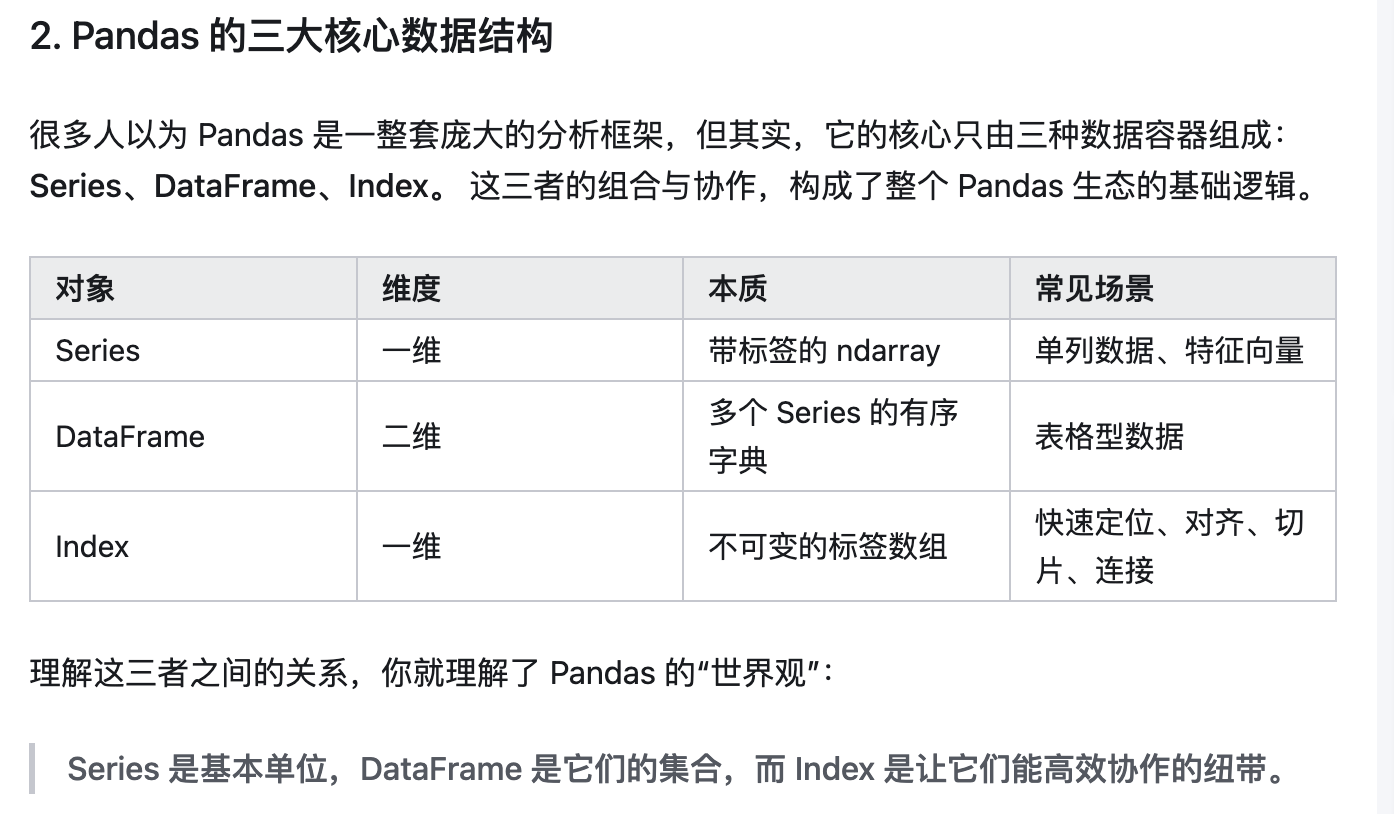

In [11]:
import pandas as pd


s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
print(s['b'])

20


In [4]:
s1 = pd.Series([1, 2, 3], index=['a', 'b', 'c'])
s2 = pd.Series([10, 20, 30], index=['b', 'c', 'd'])
print(s1 + s2)

a     NaN
b    12.0
c    23.0
d     NaN
dtype: float64


In [ ]:
Series
├── index      行索引
├── name       列名
└── _mgr       单列数据管理器

In [16]:
type(s.index),type(s.name),type(s._mgr),s.index,s.name,s._mgr

(pandas.Index,
 NoneType,
 pandas.core.internals.managers.SingleBlockManager,
 Index(['a', 'b', 'c'], dtype='str'),
 None,
 SingleBlockManager
 Items: Index(['a', 'b', 'c'], dtype='str')
 NumpyBlock: 3 dtype: int64)

In [17]:
df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie'],
    'score': [85, 90, 88]
})
print(df.loc[1, 'score'])


90


In [ ]:
DataFrame
├── index      行索引，Index 对象
├── columns    列索引，也是 Index 对象
└── _mgr       数据管理器，BlockManager / ArrayManager
      └── 真正存储每列/每块的数据

In [20]:
type(df.index), type(df.columns), type(df._mgr),df.index, df.columns, df._mgr

(pandas.RangeIndex,
 pandas.Index,
 pandas.core.internals.managers.BlockManager,
 RangeIndex(start=0, stop=3, step=1),
 Index(['name', 'score'], dtype='str'),
 BlockManager
 Items: Index(['name', 'score'], dtype='str')
 Axis 1: RangeIndex(start=0, stop=3, step=1)
 ExtensionBlock: slice(0, 1, 1), 1 x 3, dtype: str
 NumpyBlock: slice(1, 2, 1), 1 x 3, dtype: int64)

In [23]:
import pandas as pd

df = pd.DataFrame({
    "a": [1, 2, 3],        # int
    "b": [4, 5, 6],        # int
    "c": [1.1, 2.2, 3.3],  # float
})
df._mgr

BlockManager
Items: Index(['a', 'b', 'c'], dtype='str')
Axis 1: RangeIndex(start=0, stop=3, step=1)
NumpyBlock: slice(0, 2, 1), 2 x 3, dtype: int64
NumpyBlock: slice(2, 3, 1), 1 x 3, dtype: float64

In [25]:
for blk in df._mgr.blocks:
    print("dtype:", blk.dtype)
    print("mgr_locs:", blk.mgr_locs) #slice[start, stop, step)， 对应第几列
    print("values shape:", blk.values.shape)
    print(blk.values)
    print()

dtype: int64
mgr_locs: BlockPlacement(slice(0, 2, 1))
values shape: (2, 3)
[[1 2 3]
 [4 5 6]]

dtype: float64
mgr_locs: BlockPlacement(slice(2, 3, 1))
values shape: (1, 3)
[[1.1 2.2 3.3]]



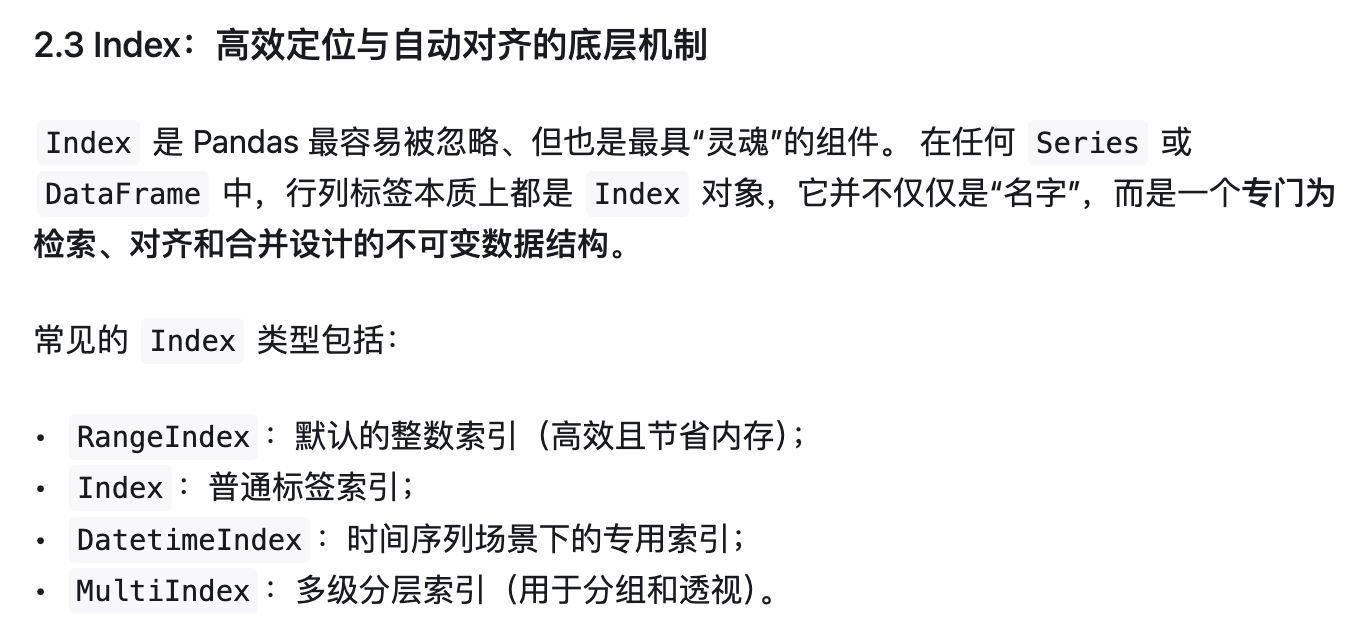

Index 的核心作用有三点：

✅ 定位（Location） 快速查找、切片与选择。内部使用哈希表或二分查找实现高效访问。 例如：

df.loc['2025-01-01']
会在毫秒级完成日期索引的定位。

✅ 对齐（Alignment） 在多个 Series 或 DataFrame 运算时，自动按索引匹配标签，而无需显式 join。 这使得 Pandas 可以像电子表格一样自动对齐行列。

✅ 唯一性与一致性保证 索引的不可变特性保证数据结构稳定，防止计算过程中错配行号。 在 merge / join / concat 等操作中，Index 扮演着主键（key）的角色。


In [29]:
df= pd.DataFrame({
    "int1":[1,2,3],
    "int2":[4,5,6],
    "float":[1.1,2.2,3.3],
})
df

,int1,int2,float
0,1,4,1.1
1,2,5,2.2
2,3,6,3.3


In [40]:
df.values,type(df.values)

(array([[1. , 4. , 1.1],
        [2. , 5. , 2.2],
        [3. , 6. , 3.3]]),
 numpy.ndarray)

In [41]:
df.index,type(df.index)

(RangeIndex(start=0, stop=3, step=1), pandas.RangeIndex)

In [42]:
df.columns,type(df.columns)

(Index(['int1', 'int2', 'float'], dtype='str'), pandas.Index)

In [39]:
print(df.info(memory_usage='deep'))

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   int1    3 non-null      int64  
 1   int2    3 non-null      int64  
 2   float   3 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 204.0 bytes
None


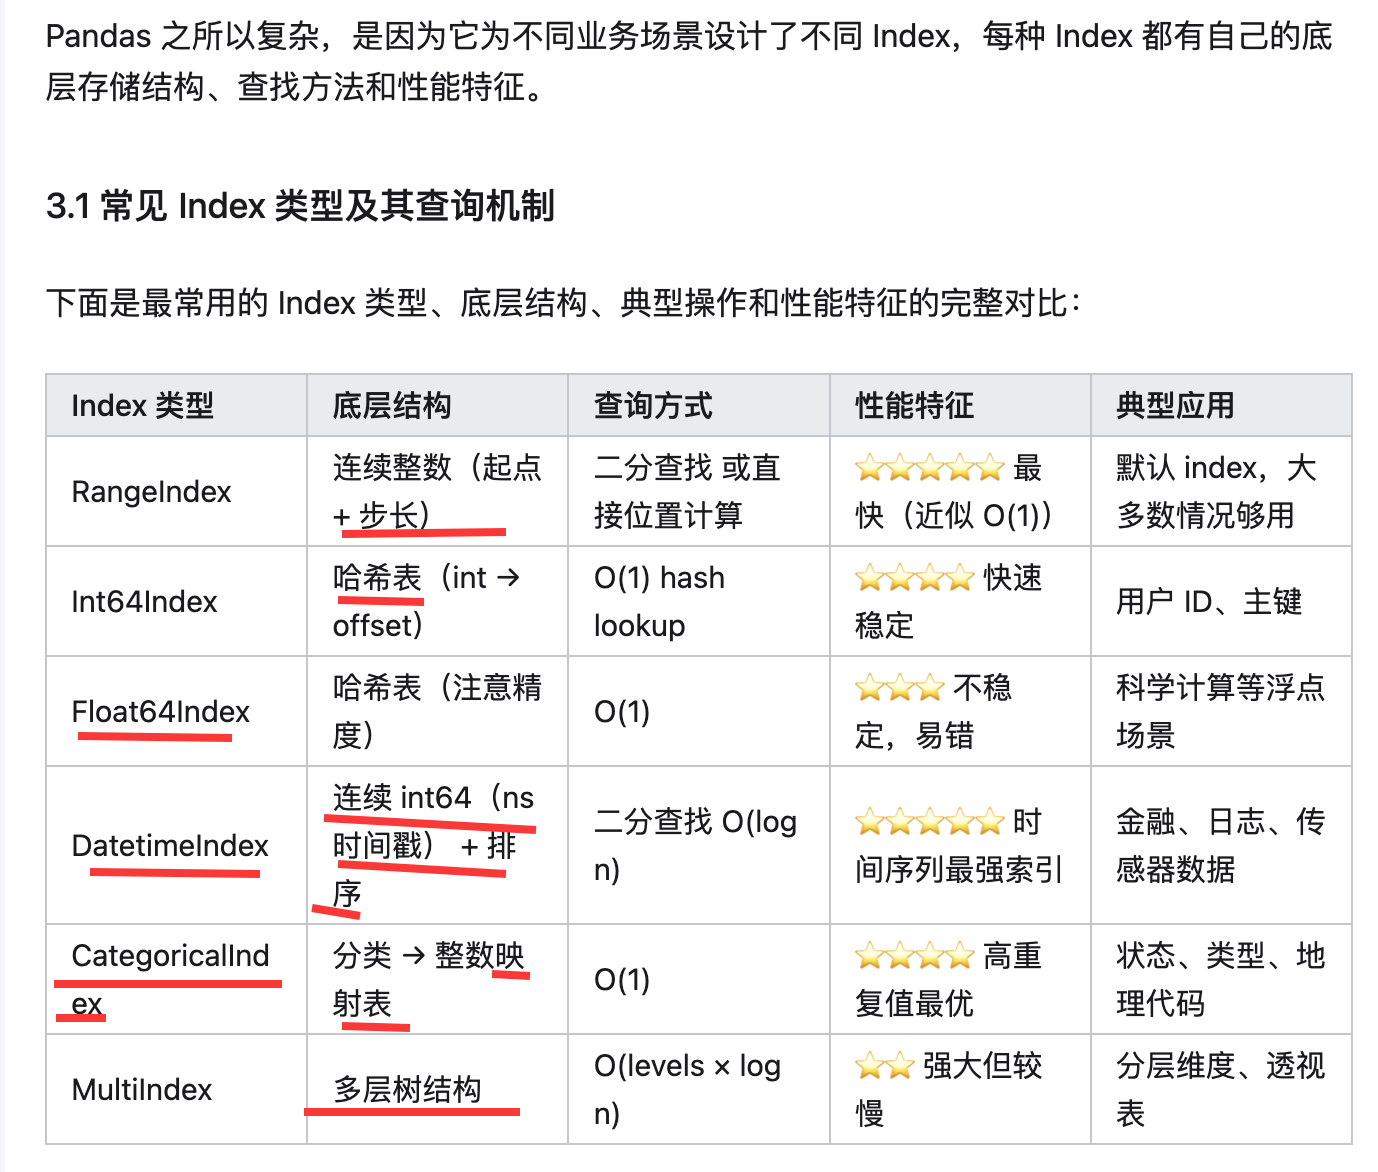

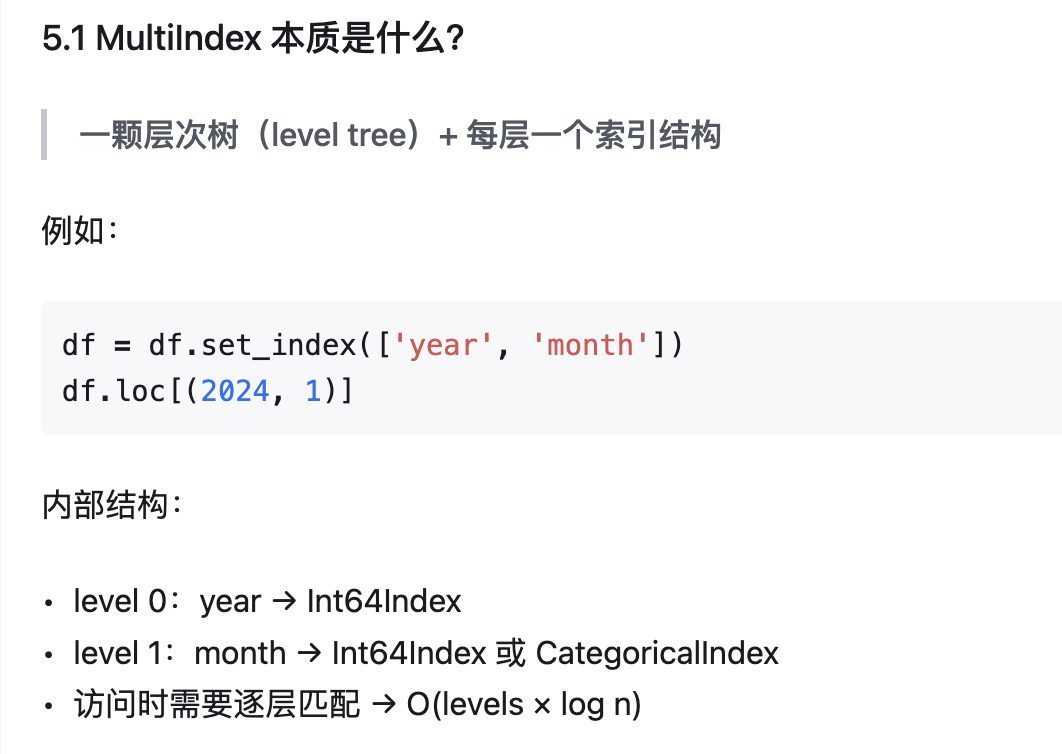

理解 GroupBy 的核心思想
Pandas 的 GroupBy 实现基于经典的数据处理范式：

1）Split —— 按组拆分数据

将数据按 key（如 city、user_id、month）拆分成多个组。

使用哈希表（如 category/int64）
或基于排序的分组（如 datetime）

2）Apply —— 对每组做批量计算

对每个子集使用聚合函数：

内置的 C 层聚合（最快）
NumPy ufunc（次快）
Python 函数（最慢，仅用于复杂逻辑）

3）Combine —— 汇总为新的 DataFrame / Series

按照 group key 排序、对齐，构建结果结构。

In [45]:
import pandas as pd
import numpy as np

# 构造示例数据
np.random.seed(0)
df = pd.DataFrame({
    'city': np.random.choice(['Beijing','Shanghai','Guangzhou'], size=10_000),
    'salary': np.random.randint(3000, 15000, size=10_000)
})
df

,city,salary
0,Beijing,5706
1,Shanghai,14496
2,Beijing,13014
3,Shanghai,4806
4,Shanghai,5271
...,...,...
9995,Beijing,11762
9996,Shanghai,6764
9997,Shanghai,11299
9998,Beijing,6408


In [47]:
# 按城市求平均工资
avg_salary = df.groupby('city')['salary'].mean() #Split–Apply–Combine
print(avg_salary) 

city
Beijing      9001.072602
Guangzhou    8907.396914
Shanghai     9018.071491
Name: salary, dtype: float64


In [54]:
# 每个城市 salary 做中心化
df.groupby('city')['salary'].transform(lambda x: x - x.mean()) #适合“按组计算一个值，再广播回组内”

0      -3295.072602
1       5477.928509
2       4012.927398
3      -4212.071491
4      -3747.071491
           ...     
9995    2760.927398
9996   -2254.071491
9997    2280.928509
9998   -2593.072602
9999    3928.927398
Name: salary, Length: 10000, dtype: float64

In [53]:
df.groupby('city').apply(lambda x: x.iloc[-1])  # 每组取最后一行

,salary,salary_centered
city,,
Beijing,12930.0,3928.927398
Guangzhou,13252.0,4344.603086
Shanghai,11299.0,2280.928509
